In [ ]:
%pip --version
%pip install numpy tqdm scikit-learn


In [1]:
import os
import glob
import shutil
import random
import numpy as np
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt

# ================= CONFIG =================

INPUT_DIR = r"C:\Users\lnakh\Downloads\dataset\data_image"
OUTPUT_DIR = r"D:\LuanVanTotNghiep\backend-AI\dataset123"

BALANCE_PERCENTAGE = 0.10
TEST_SIZE = 0.2
K_FOLDS = 5

random.seed(42)

# ================= HELPER =================

def print_stats(title, labels):
    counter = Counter(labels)
    total = len(labels)

    print(f"\n===== {title} =====")
    print(f"Total images: {total}")

    for cls, count in sorted(counter.items()):
        print(f"{cls}: {count}")

def plot_distribution(labels, title, save_dir="plot123"):

    os.makedirs(save_dir, exist_ok=True)

    counter = Counter(labels)

    classes = list(counter.keys())
    counts = list(counter.values())

    # 🔥 Sort theo số lượng (rất quan trọng)
    sorted_data = sorted(zip(classes, counts), key=lambda x: x[1])
    classes, counts = zip(*sorted_data)

    plt.figure(figsize=(10, 8))  # 🔥 to hơn

    plt.barh(classes, counts)

    plt.title(title)
    plt.xlabel("Number of images")
    plt.ylabel("Classes")

    plt.tight_layout()

    save_path = os.path.join(save_dir, title.replace(" ", "_") + ".png")
    plt.savefig(save_path)
    plt.close()

    print(f"Saved: {save_path}")

# ================= SCAN DATASET =================

def scan_dataset():

    classes = [
        d for d in os.listdir(INPUT_DIR)
        if os.path.isdir(os.path.join(INPUT_DIR, d))
    ]

    class_images = {}

    for cls in classes:

        cls_dir = os.path.join(INPUT_DIR, cls)

        images = glob.glob(os.path.join(cls_dir, "*.*"))

        images = [
            img for img in images
            if img.lower().endswith((".jpg",".jpeg",".png",".bmp"))
        ]

        class_images[cls] = images

    return class_images


# ================= BALANCE DATASET =================

def balance_dataset(class_images):

    class_counts = {cls: len(imgs) for cls, imgs in class_images.items()}

    min_count = min(class_counts.values())

    max_allowed = int(min_count + min_count * BALANCE_PERCENTAGE)

    print("\n===== BALANCE INFO =====")
    print("Min class size:", min_count)
    print("Max allowed per class:", max_allowed)

    final_paths = []
    final_labels = []

    for cls, imgs in class_images.items():

        if len(imgs) > max_allowed:
            selected = random.sample(imgs, max_allowed)
        else:
            selected = imgs

        for img in selected:
            final_paths.append(img)
            final_labels.append(cls)

    return np.array(final_paths), np.array(final_labels)


# ================= COPY FILE =================

def copy_files(paths, labels, subset):

    for img_path, label in tqdm(zip(paths, labels), total=len(paths), desc=subset):

        dst_dir = os.path.join(OUTPUT_DIR, subset, label)

        os.makedirs(dst_dir, exist_ok=True)

        shutil.copy(img_path, os.path.join(dst_dir, os.path.basename(img_path)))


# ================= MAIN PROCESS =================

def create_dataset():

    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR)

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print("Scanning dataset...")

    class_images = scan_dataset()

    # ===== BEFORE BALANCE =====
    all_labels = []
    for cls, imgs in class_images.items():
        all_labels += [cls] * len(imgs)

    print_stats("BEFORE BALANCE", all_labels)
    plot_distribution(all_labels, "Before Balance")

    # ===== BALANCE =====
    image_paths, labels = balance_dataset(class_images)

    print_stats("AFTER BALANCE", labels)
    plot_distribution(labels, "After Balance")


    # ===== TRAIN / TEST SPLIT =====

    X_train, X_test, y_train, y_test = train_test_split(
        image_paths,
        labels,
        test_size=TEST_SIZE,
        stratify=labels,
        random_state=42
    )

    print_stats("TRAIN SET", y_train)
    plot_distribution(y_train, "Train Set")
    print_stats("TEST SET", y_test)
    plot_distribution(y_test, "Test Set")
    print("\nSaving TEST set...")
    copy_files(X_test, y_test, "test")

    # ===== KFOLD =====

    skf = StratifiedKFold(
        n_splits=K_FOLDS,
        shuffle=True,
        random_state=42
    )

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):

        fold_name = f"fold_{fold_idx+1}"

        print(f"\n========== {fold_name} ==========")

        X_tr = X_train[train_idx]
        y_tr = y_train[train_idx]

        X_val = X_train[val_idx]
        y_val = y_train[val_idx]

        if fold_idx == 0:
             print_stats(f"{fold_name} TRAIN", y_tr)
             plot_distribution(y_tr, f"{fold_name} TRAIN")
             print_stats(f"{fold_name} VAL", y_val)
             plot_distribution(y_val, f"{fold_name} VAL")

        # ===== COPY TRAIN =====
        for img_path, label in tqdm(zip(X_tr, y_tr), total=len(X_tr), desc=f"{fold_name} train"):

            dst_dir = os.path.join(OUTPUT_DIR, fold_name, "train", label)

            os.makedirs(dst_dir, exist_ok=True)

            shutil.copy(img_path, os.path.join(dst_dir, os.path.basename(img_path)))

        # ===== COPY VAL =====
        for img_path, label in tqdm(zip(X_val, y_val), total=len(X_val), desc=f"{fold_name} val"):

            dst_dir = os.path.join(OUTPUT_DIR, fold_name, "val", label)

            os.makedirs(dst_dir, exist_ok=True)

            shutil.copy(img_path, os.path.join(dst_dir, os.path.basename(img_path)))

    print("\nDataset creation completed!")


# ================= RUN =================

create_dataset()

Scanning dataset...

===== BEFORE BALANCE =====
Total images: 9967
Banana: 247
Basil: 274
Chili: 483
Corn: 1220
Cucumber: 1323
Eggplant: 1553
Ginger: 1959
Guava: 409
Lemon: 249
Mango: 498
Orange: 241
Papaya: 255
Rose: 270
Soybean: 483
Tomato: 251
Watermelon: 252
Saved: plot123\Before_Balance.png

===== BALANCE INFO =====
Min class size: 241
Max allowed per class: 265

===== AFTER BALANCE =====
Total images: 4145
Banana: 247
Basil: 265
Chili: 265
Corn: 265
Cucumber: 265
Eggplant: 265
Ginger: 265
Guava: 265
Lemon: 249
Mango: 265
Orange: 241
Papaya: 255
Rose: 265
Soybean: 265
Tomato: 251
Watermelon: 252
Saved: plot123\After_Balance.png

===== TRAIN SET =====
Total images: 3316
Banana: 197
Basil: 212
Chili: 212
Corn: 212
Cucumber: 212
Eggplant: 212
Ginger: 212
Guava: 212
Lemon: 199
Mango: 212
Orange: 193
Papaya: 204
Rose: 212
Soybean: 212
Tomato: 201
Watermelon: 202
Saved: plot123\Train_Set.png

===== TEST SET =====
Total images: 829
Banana: 50
Basil: 53
Chili: 53
Corn: 53
Cucumber: 53
Egg

test: 100%|██████████| 829/829 [00:03<00:00, 243.76it/s]



========== fold_1 ==========

===== fold_1 TRAIN =====
Total images: 2652
Banana: 158
Basil: 170
Chili: 170
Corn: 170
Cucumber: 169
Eggplant: 169
Ginger: 170
Guava: 170
Lemon: 159
Mango: 169
Orange: 155
Papaya: 163
Rose: 169
Soybean: 169
Tomato: 160
Watermelon: 162
Saved: plot123\fold_1_TRAIN.png

===== fold_1 VAL =====
Total images: 664
Banana: 39
Basil: 42
Chili: 42
Corn: 42
Cucumber: 43
Eggplant: 43
Ginger: 42
Guava: 42
Lemon: 40
Mango: 43
Orange: 38
Papaya: 41
Rose: 43
Soybean: 43
Tomato: 41
Watermelon: 40
Saved: plot123\fold_1_VAL.png


fold_1 val: 100%|██████████| 664/664 [00:03<00:00, 211.75it/s]



========== fold_2 ==========


...


========== fold_4 ==========


fold_4 val: 100%|██████████| 663/663 [00:00<00:00, 897.19it/s]



========== fold_5 ==========


fold_5 val: 100%|██████████| 663/663 [00:01<00:00, 657.42it/s]


Dataset creation completed!


C:\Users\lnakh\AppData\Local\Temp\ipykernel_6896\3096666059.py:42: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(CONFIG_FINAL['IMG_SIZE'][0], CONFIG_FINAL['IMG_SIZE'][1], always_apply=True),
C:\Users\lnakh\AppData\Local\Temp\ipykernel_6896\3096666059.py:49: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(num_shadows_lower=1, num_shadows_upper=2,


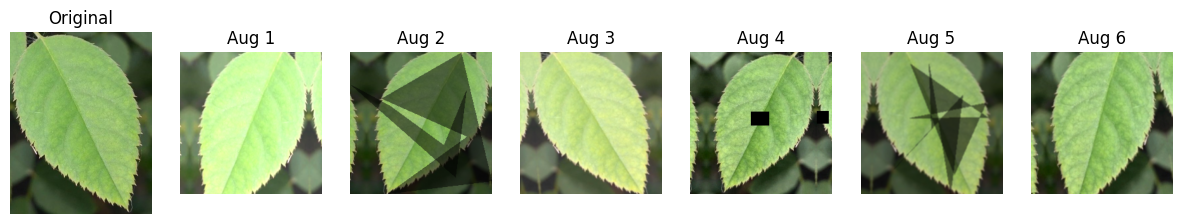

In [10]:
import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math

CONFIG_FINAL = {
    'IMG_SIZE': (224, 224),
    'LOAD_SIZE': (256, 256),
    'BATCH_SIZE': 64,
    'NUM_CLASSES': 16,
    
    # THAM SỐ TRUYỀN VÀO: Chọn Model và Cấu hình (Level) muốn dùng
    'TARGET_MODEL': 'EfficientNetB0',
    'TARGET_LEVEL': 2,                
    'OPTIMAL_EPOCHS': {
        1: 37,  # 25 (log) + 20% bù data = ~30
        2: 52   # 26 (log) + 15% bù data = ~30
    },
    'LR': {1: 1e-3, 2: 1e-4, 3: 1e-5},
    
    # THƯ MỤC
    'TEST_DIR': '/kaggle/input/datasets/khilnguynanh/plantleavedatasetupdate/dataset/test',       
    'OUTPUT_DIR': './final_results/EfficientNetB0'
}

def get_augmentation_pipeline():
    return A.Compose([
        # --- NHÓM 1: CHUẨN HÓA HÌNH HỌC BAN ĐẦU ---
        A.LongestMaxSize(max_size=256),
        A.PadIfNeeded(min_height=256, min_width=256, border_mode=cv2.BORDER_REFLECT_101),
        
        # --- NHÓM 2: BIẾN DẠNG HÌNH HỌC (GEOMETRIC) ---
        A.Rotate(limit=25, border_mode=cv2.BORDER_REFLECT_101, p=0.7),
        A.HorizontalFlip(p=0.5),
        A.Perspective(scale=(0.02, 0.04), p=0.3),
        
        # --- NHÓM 3: ĐƯA VỀ KÍCH THƯỚC CHUẨN (CROP/RESIZE) ---
        # Ưu tiên Crop ngẫu nhiên trước để đa dạng vị trí lá
        A.RandomResizedCrop(size=CONFIG_FINAL['IMG_SIZE'], scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.7),
        # Resize chốt hạ nếu RandomResizedCrop không chạy
        A.Resize(CONFIG_FINAL['IMG_SIZE'][0], CONFIG_FINAL['IMG_SIZE'][1], always_apply=True),
        
        # --- NHÓM 4: ÁNH SÁNG & MÀU SẮC (PHOTOMETRIC) ---
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2),
            A.RandomGamma(gamma_limit=(90, 110)),
            A.CLAHE(clip_limit=2),
            A.RandomShadow(num_shadows_lower=1, num_shadows_upper=2, 
                           shadow_roi=(0, 0, 1, 1), shadow_dimension=5, p=1),
        ], p=0.8),
        
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=12, val_shift_limit=8, p=0.4),

        # --- NHÓM 5: LỖI CAMERA (NOISE/BLUR) ---
        # Nên làm sau cùng của phần màu sắc để nhiễu hạt trông thật hơn
        A.OneOf([
            A.ISONoise(color_shift=(0.01, 0.03), intensity=(0.1, 0.4)),
            A.MotionBlur(blur_limit=3),
            A.GaussianBlur(blur_limit=(3, 5)),
            A.Defocus(radius=(1, 2), alias_blur=(0.1, 0.3))
        ], p=0.4),

        # --- NHÓM 6: CHE KHUẤT (OCCLUSION) ---
        A.CoarseDropout(
            num_holes_range=(1, 2), 
            hole_height_range=(10, 30), 
            hole_width_range=(10, 30), 
            fill=0, p=0.25
        )
    ])

def compare_with_original(image_path, transform, n=5):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 5))

    # ảnh gốc
    plt.subplot(1, n+1, 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis('off')

    # ảnh augment
    for i in range(n):
        aug = transform(image=image)['image']
        plt.subplot(1, n+1, i+2)
        plt.imshow(aug)
        plt.title(f'Aug {i+1}')
        plt.axis('off')

    plt.show()
compare_with_original(r"D:\LuanVanTotNghiep\backend-AI\cropped.png", get_augmentation_pipeline(), n=6)


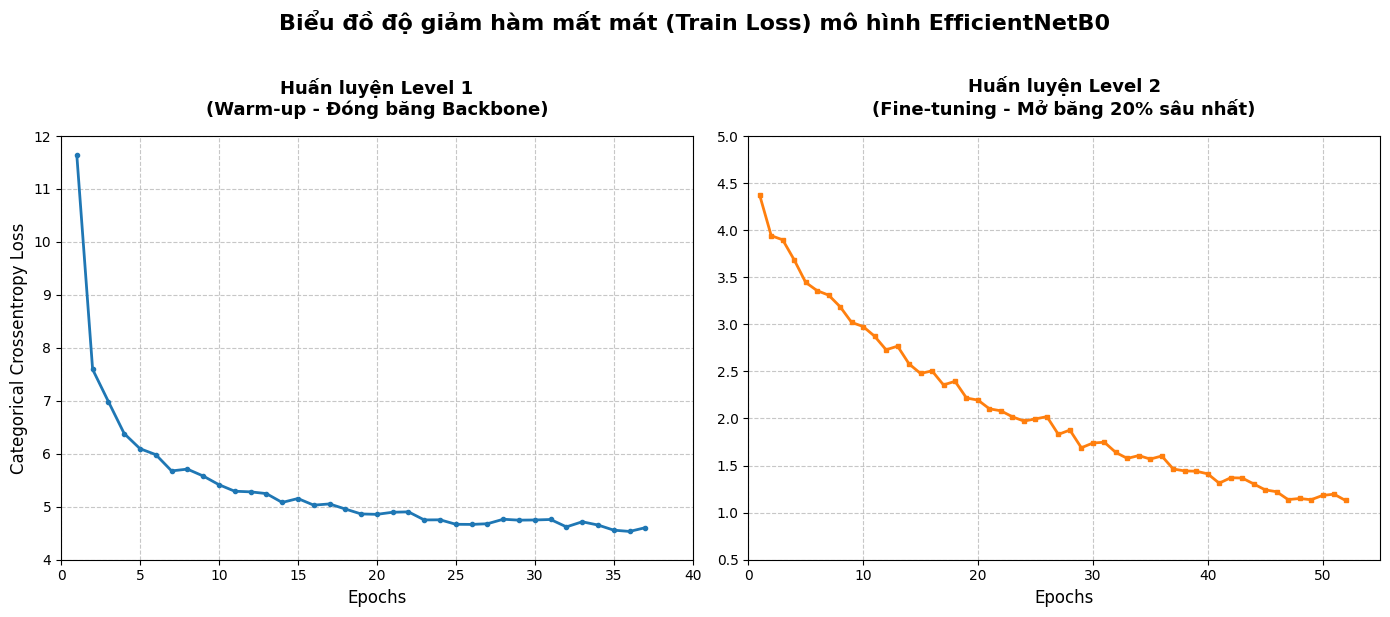

In [1]:
import matplotlib.pyplot as plt

# Dữ liệu Loss của Level 1 (37 Epochs)
loss_level_1 = [
    11.635970, 7.595016, 6.985203, 6.381652, 6.096464, 5.984387, 5.676834, 5.710691, 5.580843, 5.416362,
    5.293140, 5.281640, 5.248647, 5.081508, 5.155377, 5.030446, 5.053522, 4.957416, 4.864193, 4.856993,
    4.896477, 4.903451, 4.751194, 4.753722, 4.669007, 4.666637, 4.679458, 4.764138, 4.747036, 4.750622,
    4.759510, 4.620041, 4.716449, 4.655009, 4.558009, 4.534126, 4.605462
]

# Dữ liệu Loss của Level 2 (52 Epochs)
loss_level_2 = [
    4.369651, 3.941573, 3.897441, 3.684584, 3.445264, 3.357458, 3.309952, 3.186726, 3.020536, 2.976906,
    2.873653, 2.729602, 2.768110, 2.579640, 2.478155, 2.505760, 2.356276, 2.394978, 2.217519, 2.195172,
    2.102778, 2.081267, 2.017843, 1.972636, 1.995421, 2.019786, 1.830911, 1.877495, 1.689082, 1.739430,
    1.747926, 1.639179, 1.576050, 1.606201, 1.569032, 1.601666, 1.463548, 1.443102, 1.439899, 1.412306,
    1.313045, 1.370536, 1.367797, 1.305414, 1.241984, 1.222252, 1.138503, 1.150413, 1.137022, 1.182984,
    1.196295, 1.129268
]

# Tạo danh sách số thứ tự Epoch tương ứng
epochs_1 = list(range(1, len(loss_level_1) + 1))
epochs_2 = list(range(1, len(loss_level_2) + 1))

# Khởi tạo Figure và 2 Subplots nằm ngang
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- ĐỒ THỊ 1: LEVEL 1 ---
axes[0].plot(epochs_1, loss_level_1, color='#1f77b4', linewidth=2, marker='o', markersize=3)
axes[0].set_title('Huấn luyện Level 1\n(Warm-up - Đóng băng Backbone)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Categorical Crossentropy Loss', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
# Giới hạn trục Y và X cho đẹp
axes[0].set_xlim(0, 40)
axes[0].set_ylim(4.0, 12.0)

# --- ĐỒ THỊ 2: LEVEL 2 ---
axes[1].plot(epochs_2, loss_level_2, color='#ff7f0e', linewidth=2, marker='s', markersize=3)
axes[1].set_title('Huấn luyện Level 2\n(Fine-tuning - Mở băng 20% sâu nhất)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Epochs', fontsize=12)
# Không cần lặp lại tên trục Y để tránh rối mắt
axes[1].grid(True, linestyle='--', alpha=0.7)
# Giới hạn trục Y và X cho đẹp
axes[1].set_xlim(0, 55)
axes[1].set_ylim(0.5, 5.0)

# Tiêu đề tổng quát cho cả Hình
fig.suptitle('Biểu đồ độ giảm hàm mất mát (Train Loss) mô hình EfficientNetB0', fontsize=16, fontweight='bold', y=1.02)

# Tự động căn chỉnh khoảng cách
plt.tight_layout()

# Lưu hình ảnh với độ phân giải cao (300 DPI) chuẩn in ấn luận văn
plt.savefig('Train_Loss_EfficientNetB0_Subplots.png', dpi=300, bbox_inches='tight')

# Hiển thị biểu đồ
plt.show()

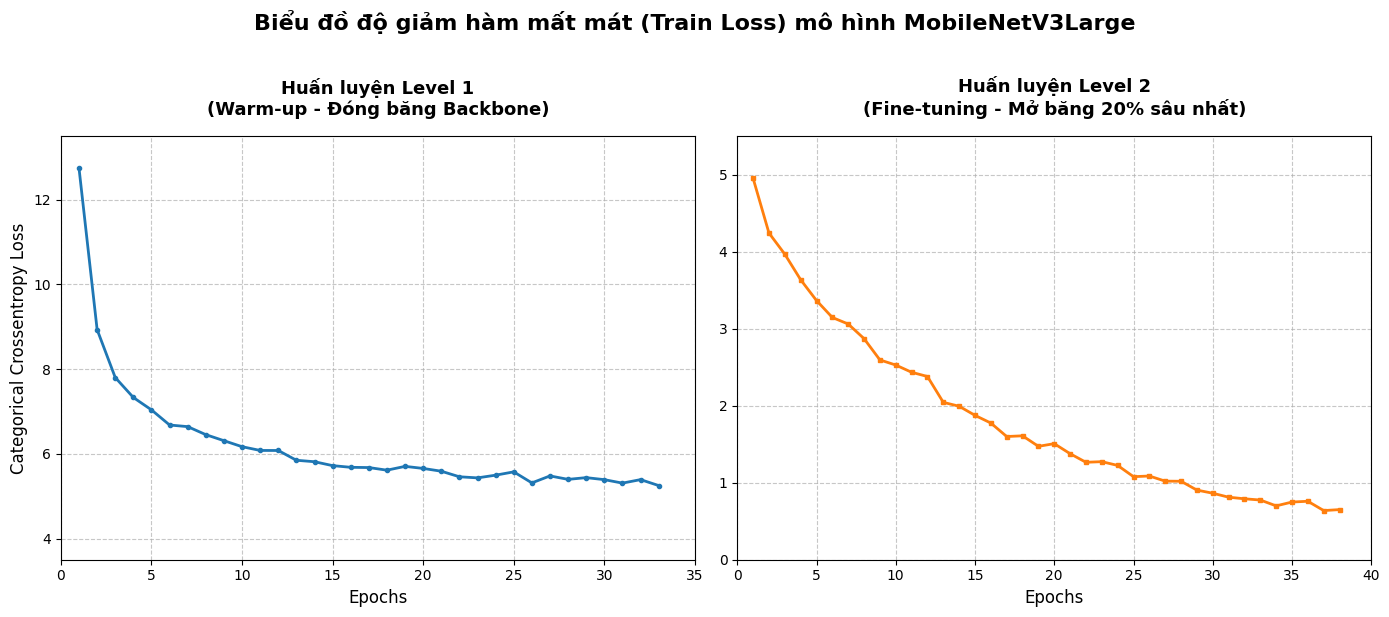

Đã lưu thành công: Train_Loss_MobileNetV3Large_Subplots.png


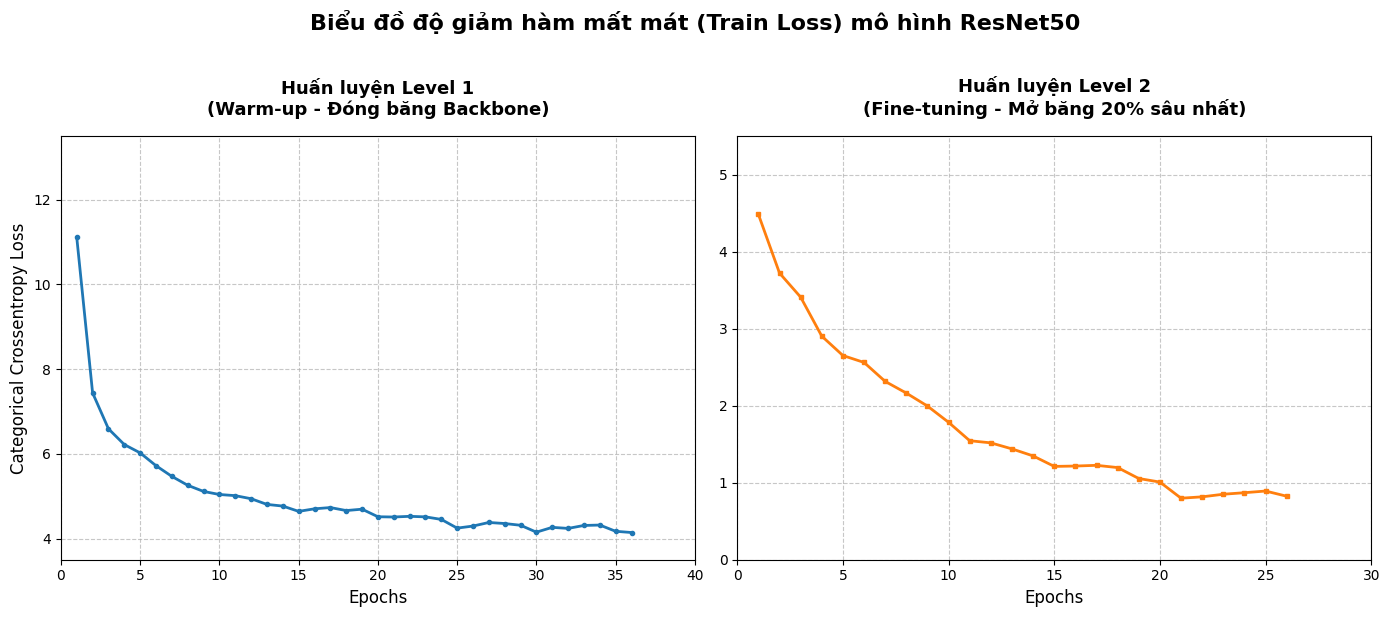

Đã lưu thành công: Train_Loss_ResNet50_Subplots.png


In [2]:
import matplotlib.pyplot as plt

# ==================== DỮ LIỆU LOG ====================

# 1. Dữ liệu MobileNetV3Large
mobilenet_l1 = [
    12.738518, 8.931364, 7.800088, 7.329098, 7.036324, 6.679596, 6.641075, 6.451901, 6.309284, 6.167821, 
    6.079125, 6.078324, 5.847501, 5.812840, 5.720814, 5.681116, 5.675334, 5.613367, 5.703394, 5.654680, 
    5.588876, 5.457577, 5.431750, 5.495659, 5.573703, 5.313150, 5.477962, 5.396549, 5.437474, 5.389900, 
    5.307941, 5.390639, 5.250519
]
mobilenet_l2 = [
    4.951357, 4.241390, 3.966261, 3.634681, 3.364683, 3.144443, 3.059807, 2.870048, 2.593647, 2.527232, 
    2.433613, 2.378356, 2.042884, 1.992264, 1.874081, 1.774171, 1.599256, 1.608540, 1.471838, 1.506616, 
    1.376341, 1.264784, 1.272995, 1.224035, 1.078100, 1.086716, 1.020091, 1.018538, 0.903899, 0.863296, 
    0.811764, 0.791019, 0.774955, 0.699092, 0.748771, 0.758864, 0.638113, 0.650532
]

# 2. Dữ liệu ResNet50
resnet_l1 = [
    11.108041, 7.437787, 6.589668, 6.217927, 6.021535, 5.719423, 5.466863, 5.257106, 5.111537, 5.039539, 
    5.012184, 4.939688, 4.805418, 4.766306, 4.641330, 4.701502, 4.731205, 4.660335, 4.692929, 4.514230, 
    4.508140, 4.524188, 4.511571, 4.451512, 4.245921, 4.294782, 4.379149, 4.354128, 4.313191, 4.150440, 
    4.264008, 4.239131, 4.308820, 4.318336, 4.171017, 4.142151
]
resnet_l2 = [
    4.483705, 3.721033, 3.408513, 2.902070, 2.650748, 2.560802, 2.314656, 2.163200, 1.994897, 1.783766, 
    1.544736, 1.517088, 1.438645, 1.347403, 1.211258, 1.216104, 1.225370, 1.196201, 1.054215, 1.008060, 
    0.798419, 0.816461, 0.850128, 0.869972, 0.891660, 0.824243
]

# ==================== HÀM VẼ BIỂU ĐỒ ====================

def plot_loss_subplots(model_name, loss_l1, loss_l2, max_x1, max_x2):
    epochs_1 = list(range(1, len(loss_l1) + 1))
    epochs_2 = list(range(1, len(loss_l2) + 1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- ĐỒ THỊ 1: LEVEL 1 ---
    axes[0].plot(epochs_1, loss_l1, color='#1f77b4', linewidth=2, marker='o', markersize=3)
    axes[0].set_title('Huấn luyện Level 1\n(Warm-up - Đóng băng Backbone)', fontsize=13, fontweight='bold', pad=15)
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Categorical Crossentropy Loss', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.7)
    axes[0].set_xlim(0, max_x1)
    axes[0].set_ylim(3.5, 13.5) # Mở rộng nhẹ trục Y để lấy hết biên độ 12.7 của MobileNet

    # --- ĐỒ THỊ 2: LEVEL 2 ---
    axes[1].plot(epochs_2, loss_l2, color='#ff7f0e', linewidth=2, marker='s', markersize=3)
    axes[1].set_title('Huấn luyện Level 2\n(Fine-tuning - Mở băng 20% sâu nhất)', fontsize=13, fontweight='bold', pad=15)
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].set_xlim(0, max_x2)
    axes[1].set_ylim(0.0, 5.5)

    # Tiêu đề tổng
    fig.suptitle(f'Biểu đồ độ giảm hàm mất mát (Train Loss) mô hình {model_name}', fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    filename = f'Train_Loss_{model_name}_Subplots.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Đã lưu thành công: {filename}")

# ==================== THỰC THI VẼ 2 MÔ HÌNH ====================

# Vẽ MobileNetV3Large (Trục X cho Level 1 là 35, Level 2 là 40 cho đẹp)
plot_loss_subplots("MobileNetV3Large", mobilenet_l1, mobilenet_l2, max_x1=35, max_x2=40)

# Vẽ ResNet50 (Trục X cho Level 1 là 40, Level 2 là 30 cho đẹp)
plot_loss_subplots("ResNet50", resnet_l1, resnet_l2, max_x1=40, max_x2=30)

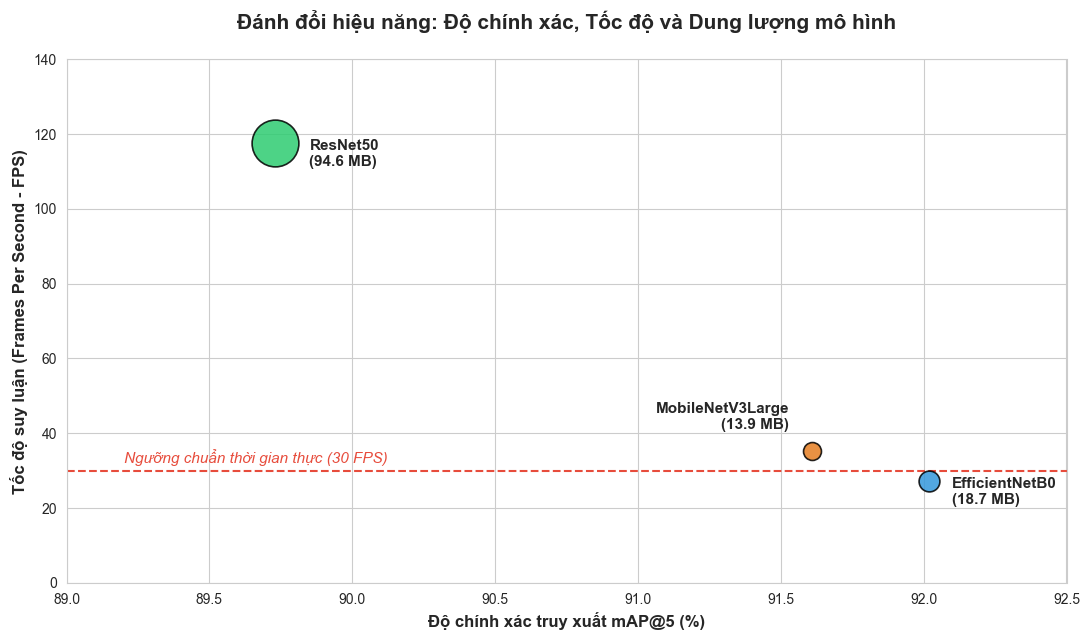

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ================= DỮ LIỆU ĐÁNH GIÁ (PROTOCOL 3) =================
models = ['EfficientNetB0', 'MobileNetV3Large', 'ResNet50']
mAP5_scores = [92.02, 91.61, 89.73]  # Trục X (%)
fps_scores = [36.56, 28.42, 8.50]  # Trục Y (FPS)
model_sizes = [18.7, 13.9, 94.6]     # Dung lượng (MB)

# ================= VẼ BIỂU ĐỒ =================
plt.figure(figsize=(11, 6.5))
sns.set_style("whitegrid")

# Mã màu chuyên nghiệp
colors = ['#3498db', '#e67e22', '#2ecc71'] 

for i in range(len(models)):
    # Thu nhỏ tỷ lệ bong bóng lại cho tinh tế (nhân với 12 thay vì 25)
    area = model_sizes[i] * 12 
    
    plt.scatter(
        mAP5_scores[i], fps_scores[i], 
        s=area, 
        c=colors[i], 
        alpha=0.85, 
        edgecolors='black', 
        linewidth=1.2,
        zorder=3 # Đẩy bong bóng nổi lên trên các đường lưới
    )
    
    # Text ghi chú: Tên mô hình + Dung lượng
    label_text = f"{models[i]}\n({model_sizes[i]} MB)"
    
    # Căn chỉnh vị trí chữ thủ công để không bao giờ đè lên bong bóng
    if models[i] == 'ResNet50':
        plt.text(mAP5_scores[i] + 0.12, fps_scores[i] - 3, label_text, fontsize=11, fontweight='bold', va='center')
    elif models[i] == 'MobileNetV3Large':
        plt.text(mAP5_scores[i] - 0.08, fps_scores[i] + 6, label_text, fontsize=11, fontweight='bold', ha='right')
    else: # EfficientNetB0
        plt.text(mAP5_scores[i] + 0.08, fps_scores[i] - 3, label_text, fontsize=11, fontweight='bold', va='center')

# ================= TRANG TRÍ HỌC THUẬT =================


plt.title("Đánh đổi hiệu năng: Độ chính xác, Tốc độ và Dung lượng mô hình\n", fontsize=15, fontweight='bold')
plt.xlabel("Độ chính xác truy xuất mAP@5 (%)", fontsize=12, fontweight='bold')
plt.ylabel("Tốc độ (ms/ảnh)", fontsize=12, fontweight='bold')

# Căn lại trục để có không gian thở cho chữ
plt.xlim(89.0, 92.5)
plt.ylim(0, 140)

plt.tight_layout()

# Lưu ảnh
filename = 'Model_Tradeoff_Clean.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()